In [1]:
import os
import pandas as pd
import numpy as np

years = list(range(2015, 2027)) 
file_by_year = {}

#here I insert the name of detailed trash file from 2015 to 2026 into the dictionary
for year in years:
    filename = f"detailed-summary-united-states {year}.csv"
    file_by_year[year] = filename

#this is to check if all 12 files are existed, it will output 20xx found if the file exists in the same folder
for year, filename in file_by_year.items():
    if os.path.exists(filename):
        print(year, "found")
    else:
        print(year, "MISSING:", filename)

2015 found
2016 found
2017 found
2018 found
2019 found
2020 found
2021 found
2022 found
2023 found
2024 found
2025 found
2026 found


In [2]:
"""
here I use 2026 as the standard years to check the column name. From 2015 to 2022, the file has 75 columns.
From 2023 to 2026, it has 62 columns. I decide to set 2026's 62 columns as standard to avoid error 
in data collection
"""

#reading column name from 2026 file
standard_year = 2026
standard_file = file_by_year[standard_year]
standard_cols = pd.read_csv(standard_file, nrows=0).columns

#clearn the space of the column name from the original file, and convert pandas column index into python list
standard_cols = standard_cols.str.strip().tolist()

print("Standard year:", standard_year)
print("Number of standard columns:", len(standard_cols))
print()
print("First 10 columns:")
print(standard_cols[:10])
print()
print("Last 10 columns:")
print(standard_cols[-10:])

Standard year: 2026
Number of standard columns: 62

First 10 columns:
['Cleanup ID', 'Zone', 'State', 'Country', 'Latitude', 'Longitude', 'Cleanup Type', 'Environment', 'Cleanup Date', 'Group Name']

Last 10 columns:
['Other plastic waste', 'Other waste (metal, paper, etc.)', 'Condoms', 'Cotton bud sticks (swabs)', 'Diapers', 'Gloves & masks (PPE)', 'Syringes', 'Tampons & applicators', 'Plastic/foam pieces', 'Total Items Collected']


In [3]:
#This cell is to check if every file has extra or missing col from the standard file
column_report = []

for year, file_name in file_by_year.items():
    #read file
    cols = pd.read_csv(file_name, nrows=0).columns
    cols = cols.str.strip().tolist()
    missing_col_year = []
    extra_col_year = []

    #check missing col
    for col in standard_cols:
        if col not in cols:
            missing_col_year.append(col)
            
    #check extra col
    for col in cols:
        if col not in standard_cols:
            extra_col_year.append(col)
            
    #add missing and extra col data into the column_report
    column_report.append({
        "year": year,
        "number_of_columns": len(cols),
        "missing_standard_columns": len(missing_col_year),
        "extra_columns": len(extra_col_year)
    })

column_report = pd.DataFrame(column_report)
column_report

,year,number_of_columns,missing_standard_columns,extra_columns
0,2015,75,0,13
1,2016,75,0,13
2,2017,75,0,13
3,2018,75,0,13
4,2019,75,0,13
5,2020,75,0,13
6,2021,75,0,13
7,2022,75,0,13
8,2023,62,0,0
9,2024,62,0,0


In [4]:
# from the file, Grocery bags (plastic) is the first col of item, and after it all col are also items
first_item_col = "Grocery bags (plastic)"

#this line find the index of all item col from the standard col that I defined in cell 2
item_cols = standard_cols[standard_cols.index(first_item_col):]

#these are not numeric values so that I need to seperate them and define them into text_cols
text_cols = [
    "Cleanup ID",
    "Zone",
    "State",
    "Country",
    "Cleanup Type",
    "Environment",
    "Cleanup Date",
    "Group Name"
]

frames = []
cleaning_log = []

for year in years:
    file_name = file_by_year[year]
    
    # read the file, i have to add low_memory=false because pandas call the low memory warning 
    df_raw = pd.read_csv(file_name, low_memory=False)
    
    # clearning space of col name
    df_raw.columns = df_raw.columns.str.strip()
    
    raw_rows = len(df_raw)
    
    # here is to delete the last row of total value, without delete it the total row will be counted as a cleanup
    #activity and influence data correctness
    id_text = df_raw["Cleanup ID"].astype(str).str.strip()
    df = df_raw[~id_text.str.contains("Totals", case=False, na=False)].copy()
    
    rows_after_removing_totals = len(df)
    
    # copy() create an independent df same as standard col
    df = df[standard_cols].copy()
    
    # insert source year to show the year of data
    df.insert(0, "source_year", year)
    
    # delete empty space for Cleanup ID
    df["Cleanup ID"] = df["Cleanup ID"].astype(str).str.strip()
    
    # change date from text to numeric value
    df["Cleanup Date"] = pd.to_datetime(df["Cleanup Date"], errors="coerce")
    
    # convert all col except text col into numeric value
    numeric_cols = [col for col in df.columns if col not in text_cols]
    
    for col in numeric_cols:
        df[col] = pd.to_numeric(df[col], errors="coerce")
    
    # convert missing value as 0, because if the item is not found in cleanup activity then it means that 
    #the count of the item is 0
    df[item_cols] = df[item_cols].fillna(0)
    
    frames.append(df)
    
    #append everything into the clearning_log
    cleaning_log.append({
        "year": year,
        "raw_rows": raw_rows,
        "rows_after_removing_totals": rows_after_removing_totals,
        "removed_rows": raw_rows - rows_after_removing_totals,
        "columns_after_cleaning": len(df.columns)
    })

# combine all the years and make clearning_log as df to check
clean = pd.concat(frames, ignore_index=True)
cleaning_log = pd.DataFrame(cleaning_log)
cleaning_log

,year,raw_rows,rows_after_removing_totals,removed_rows,columns_after_cleaning
0,2015,889,888,1,63
1,2016,5882,5881,1,63
2,2017,8492,8491,1,63
3,2018,10647,10646,1,63
4,2019,14426,14425,1,63
5,2020,18197,18196,1,63
6,2021,28247,28246,1,63
7,2022,20277,20276,1,63
8,2023,19536,19535,1,63
9,2024,17842,17841,1,63


In [5]:
#check if clean data is correct
print("Clean dataframe shape:")
print(clean.shape)

print("\nNumber of Totals rows left:")
print(clean["Cleanup ID"].astype(str).str.contains("Totals", case=False, na=False).sum())

print("\nNumber of duplicated Cleanup IDs:")
print(clean["Cleanup ID"].duplicated().sum())

print("\nNumber of missing Cleanup Dates:")
print(clean["Cleanup Date"].isna().sum())

print("\nDate range:")
print(clean["Cleanup Date"].min(), "to", clean["Cleanup Date"].max())

print("\nRows by source year:")
print(clean.groupby("source_year").size())

Clean dataframe shape:
(163102, 63)

Number of Totals rows left:
0

Number of duplicated Cleanup IDs:
0

Number of missing Cleanup Dates:
0

Date range:
2015-01-07 00:00:00 to 2026-07-07 00:00:00

Rows by source year:
source_year
2015      888
2016     5881
2017     8491
2018    10646
2019    14425
2020    18196
2021    28246
2022    20276
2023    19535
2024    17841
2025    14721
2026     3956
dtype: int64


In [6]:
#here I defined these column as unusal coastal trash, since they are not the normal plastic trash that accounts
#the majority of coastal trash in the world
unusual_cols = [
    "Lines, nets, traps, ropes, etc.",
    "Foam dock pieces",
    "Appliances (refrigerators, washers, etc.)",
    "Construction materials",
    "Tires",
    "Clothing",
    "E-cigarettes",
    "Electronic waste (phones, batteries)",
    "Footwear (shoes/slippers)",
    "Toys",
    "Other waste (metal, paper, etc.)",
    "Gloves & masks (PPE)",
    "Syringes"
]

# check if all of these col are in clean dataset
missing_unusual_cols = []

for col in unusual_cols:
    if col not in clean.columns:
        missing_unusual_cols.append(col)

missing_unusual_cols

[]

In [7]:
# extract year and month data from Cleanup Date
clean["year"] = clean["Cleanup Date"].dt.year
clean["month"] = clean["Cleanup Date"].dt.month

# Atlantic hurricane season usually is between June to Novenber 
clean["hurricane_season"] = clean["month"].between(6, 11).astype(int)

# clearn the space for zone and state 
clean["zone_name"] = clean["Zone"].astype(str).str.split(",").str[0].str.strip()
clean["state_name"] = clean["State"].astype(str).str.split(",").str[0].str.strip()

# calculate unusual debris count
clean["unusual_debris_count"] = clean[unusual_cols].sum(axis=1)

# calculate unusual share
clean["unusual_share"] = np.where(
    clean["Total Items Collected"] > 0,
    clean["unusual_debris_count"] / clean["Total Items Collected"],
    np.nan
)

clean[[
    "Cleanup ID",
    "Cleanup Date",
    "year",
    "month",
    "hurricane_season",
    "zone_name",
    "state_name",
    "Total Items Collected",
    "unusual_debris_count",
    "unusual_share"
]].head()

,Cleanup ID,Cleanup Date,year,month,hurricane_season,zone_name,state_name,Total Items Collected,unusual_debris_count,unusual_share
0,92,2015-02-19,2015,2,0,Washington,District of Columbia,4.0,1.0,0.250000
1,94,2015-02-19,2015,2,0,Washington,District of Columbia,14.0,0.0,0.000000
2,102,2015-03-10,2015,3,0,Washington,District of Columbia,17.0,1.0,0.058824
3,115,2015-03-10,2015,3,0,Washington,District of Columbia,5.0,0.0,0.000000
4,117,2015-03-18,2015,3,0,Washington,District of Columbia,8.0,0.0,0.000000


In [8]:
#here I'm trying to check the correctness of unusual data, 
print("Summary of unusual_debris_count:")
print(clean["unusual_debris_count"].describe())


print("\nSummary of unusual_share:")
print(clean["unusual_share"].describe())

#unusual share should always less than 0
print("\nNumber of unusual_share > 1:")
print((clean["unusual_share"] > 1).sum())

#these two value should be very close because we set if total collected<=0 then the unusual share is NaN
print("\nNumber of missing unusual_share:")
print(clean["unusual_share"].isna().sum())
print("\nNumber of rows with Total Items Collected <= 0:")
print((clean["Total Items Collected"] <= 0).sum())

Summary of unusual_debris_count:
count    163102.000000
mean         14.859174
std         111.255235
min           0.000000
25%           0.000000
50%           1.000000
75%           8.000000
max       14483.000000
Name: unusual_debris_count, dtype: float64

Summary of unusual_share:
count    131909.000000
mean          0.080068
std           0.145625
min           0.000000
25%           0.000000
50%           0.025641
75%           0.095238
max           1.000000
Name: unusual_share, dtype: float64

Number of unusual_share > 1:
0

Number of missing unusual_share:
31193

Number of rows with Total Items Collected <= 0:
31193


In [9]:
# only keep the rows that total items > 0  and have a correct date
model_base = clean[(clean["Total Items Collected"]>0)&(clean["Cleanup Date"].notna())].copy()

# define 75%  of the unusual share is the cutoff
#in other words, the highest 25% of unusual share as a high unusual event 
cutoff = model_base["unusual_share"].quantile(0.75)

# construct a new col that check if the unusual share is greater or equal to cutoff,
# if so, the high unusual event col will be true, otherwise be false
model_base["high_unusual_event"]=(model_base["unusual_share"]>=cutoff).astype(int)

#the cutoff value
print("Cutoff for high unusual event:")
print(cutoff)

#the number of high unusual event and number of those are not. 
#their proportion is 3:1, which satisfying cutoff is 75%
print("\nTarget counts:")
print(model_base["high_unusual_event"].value_counts())

#proportion version
print("\nTarget proportions:")
print(model_base["high_unusual_event"].value_counts(normalize=True))

Cutoff for high unusual event:
0.09523809523809523

Target counts:
high_unusual_event
0    98895
1    33014
Name: count, dtype: int64

Target proportions:
high_unusual_event
0    0.749721
1    0.250279
Name: proportion, dtype: float64


In [10]:
#check whether the target variable was constructed correctly 
#this tells how many cleanup events are left after removing rows with
#total items collected<=0 or missing cleanup date.
print("Model base shape:")
print(model_base.shape)

#this is to check whether the target variable has missing values
# high_unusual_event is the variable we want the machine learning model to predict.
# if this number is not 0, then some rows failed to receive a target label
print("\nMissing high_unusual_event:")
print(model_base["high_unusual_event"].isna().sum())

#this is to check whether unusual_share has missing values
#unusual_share was used to construct high_unusual_event.
#because model base only keeps rows with total item collected>0, unusual_share should not be missing here.
print("\nMissing unusual_share:")
print(model_base["unusual_share"].isna().sum())

#this is to compare unusual share between normal events and high unusual events
#the result tells that the max for normal event is around 0.095197 and min for high unusual event is 0.0952
#this correspond to the cutoff unusual share which is 0.952
print("\nUnusual share by target:")
print(model_base.groupby("high_unusual_event")["unusual_share"].describe())

Model base shape:
(131909, 71)

Missing high_unusual_event:
0

Missing unusual_share:
0

Unusual share by target:
                      count      mean       std       min      25%       50%  \
high_unusual_event                                                             
0                   98895.0  0.021276  0.026625  0.000000  0.00000  0.008696   
1                   33014.0  0.256184  0.203072  0.095238  0.12987  0.184211   

                         75%       max  
high_unusual_event                      
0                   0.037037  0.095197  
1                   0.292308  1.000000  


In [11]:
#define the features for the machine learning model, these are features we are using to predict 
#the future high unusual event
features = [
    "source_year",
    "year",
    "month",
    "hurricane_season",
    "zone_name",
    "state_name",
    "Latitude",
    "Longitude",
    "Cleanup Type",
    "Environment",
    "People",
    "Distance km",
    "Area km"
]

target = "high_unusual_event"

# these are some cols that we will not use in the model, but I keep it for checking the result after the model
#is complete
check_cols = [
    "Cleanup ID",
    "Cleanup Date",
    "Total Items Collected",
    "unusual_debris_count",
    "unusual_share"
]

#we create a new df by selecting these col from the model base df
model_data = model_base[check_cols + features + [target]].copy()
model_data.head()

,Cleanup ID,Cleanup Date,Total Items Collected,unusual_debris_count,unusual_share,source_year,year,month,hurricane_season,zone_name,state_name,Latitude,Longitude,Cleanup Type,Environment,People,Distance km,Area km,high_unusual_event
0,92,2015-02-19,4.0,1.0,0.250000,2015,2015,2,0,Washington,District of Columbia,38.90733,-77.04405,land,NaN,1.0,0.03,0.0,1
1,94,2015-02-19,14.0,0.0,0.000000,2015,2015,2,0,Washington,District of Columbia,38.90733,-77.04410,land,NaN,1.0,0.05,0.0,0
2,102,2015-03-10,17.0,1.0,0.058824,2015,2015,3,0,Washington,District of Columbia,38.90728,-77.04411,land,NaN,1.0,0.23,0.0,0
3,115,2015-03-10,5.0,0.0,0.000000,2015,2015,3,0,Washington,District of Columbia,38.90745,-77.04423,land,NaN,1.0,0.04,0.0,0
4,117,2015-03-18,8.0,0.0,0.000000,2015,2015,3,0,Washington,District of Columbia,38.90740,-77.04382,land,NaN,1.0,0.06,0.0,0


In [12]:
print("Model data shape:")
print(model_data.shape)

print("\nColumns:")
print(model_data.columns.tolist())

#this is to check the missing rate for each column, ML model cannot process missing value directly
print("\nMissing rate by column:")
print(model_data.isna().mean().sort_values(ascending=False))

#this is to check target distribution
#because I defined high_unusual_event using the top 25% unusual_share, the target distribution 
#should be close to 75% for 0 and 25% for 1. The result correspond to the assumption
print("\nTarget distribution:")
print(model_data[target].value_counts(normalize=True))

Model data shape:
(131909, 19)

Columns:
['Cleanup ID', 'Cleanup Date', 'Total Items Collected', 'unusual_debris_count', 'unusual_share', 'source_year', 'year', 'month', 'hurricane_season', 'zone_name', 'state_name', 'Latitude', 'Longitude', 'Cleanup Type', 'Environment', 'People', 'Distance km', 'Area km', 'high_unusual_event']

Missing rate by column:
Environment              0.746196
People                   0.001357
Distance km              0.000045
Cleanup ID               0.000000
state_name               0.000000
Area km                  0.000000
Cleanup Type             0.000000
Longitude                0.000000
Latitude                 0.000000
zone_name                0.000000
Cleanup Date             0.000000
hurricane_season         0.000000
month                    0.000000
year                     0.000000
source_year              0.000000
unusual_share            0.000000
unusual_debris_count     0.000000
Total Items Collected    0.000000
high_unusual_event       0.00000

In [13]:

clean.to_csv("coastal_cleanup_clean_all_2015_2026.csv", index=False)
model_base.to_csv("coastal_cleanup_model_base_2015_2026.csv", index=False)
model_data.to_csv("coastal_cleanup_model_data_2015_2026.csv", index=False)

print("Files saved successfully.")

Files saved successfully.


In [14]:

check_saved_file = [
    "coastal_cleanup_clean_all_2015_2026.csv",
    "coastal_cleanup_model_base_2015_2026.csv",
    "coastal_cleanup_model_data_2015_2026.csv"
]

for filename in check_saved_file:
    print("Checking:", filename)
    
    if os.path.exists(filename):
        print("Status: FOUND")
        print("File size:", os.path.getsize(filename), "bytes")
        
        # Read only the first few rows to make sure the file can be opened
        preview = pd.read_csv(filename, nrows=5)
        print("Preview shape:", preview.shape)
        print("Columns:", preview.columns.tolist()[:5], "...")
        
    else:
        print("Status: MISSING")
    
    print("-" * 60)

Checking: coastal_cleanup_clean_all_2015_2026.csv
Status: FOUND
File size: 63908803 bytes
Preview shape: (5, 70)
Columns: ['source_year', 'Cleanup ID', 'Zone', 'State', 'Country'] ...
------------------------------------------------------------
Checking: coastal_cleanup_model_base_2015_2026.csv
Status: FOUND
File size: 52443965 bytes
Preview shape: (5, 71)
Columns: ['source_year', 'Cleanup ID', 'Zone', 'State', 'Country'] ...
------------------------------------------------------------
Checking: coastal_cleanup_model_data_2015_2026.csv
Status: FOUND
File size: 17256349 bytes
Preview shape: (5, 19)
Columns: ['Cleanup ID', 'Cleanup Date', 'Total Items Collected', 'unusual_debris_count', 'unusual_share'] ...
------------------------------------------------------------


In [15]:
import matplotlib.pyplot as plt
#here we start to do some exploratory data analysis

eda_data = pd.read_csv("coastal_cleanup_model_data_2015_2026.csv")

# Convert Cleanup Date back to datetime format
eda_data["Cleanup Date"] = pd.to_datetime(eda_data["Cleanup Date"], errors="coerce")


print("EDA data shape:")
print(eda_data.shape)
print("\nColumns:")
print(eda_data.columns.tolist())
print("\nFirst 5 rows:")
display(eda_data.head())

EDA data shape:
(131909, 19)

Columns:
['Cleanup ID', 'Cleanup Date', 'Total Items Collected', 'unusual_debris_count', 'unusual_share', 'source_year', 'year', 'month', 'hurricane_season', 'zone_name', 'state_name', 'Latitude', 'Longitude', 'Cleanup Type', 'Environment', 'People', 'Distance km', 'Area km', 'high_unusual_event']

First 5 rows:


,Cleanup ID,Cleanup Date,Total Items Collected,unusual_debris_count,unusual_share,source_year,year,month,hurricane_season,zone_name,state_name,Latitude,Longitude,Cleanup Type,Environment,People,Distance km,Area km,high_unusual_event
0,92,2015-02-19,4.0,1.0,0.250000,2015,2015,2,0,Washington,District of Columbia,38.90733,-77.04405,land,NaN,1.0,0.03,0.0,1
1,94,2015-02-19,14.0,0.0,0.000000,2015,2015,2,0,Washington,District of Columbia,38.90733,-77.04410,land,NaN,1.0,0.05,0.0,0
2,102,2015-03-10,17.0,1.0,0.058824,2015,2015,3,0,Washington,District of Columbia,38.90728,-77.04411,land,NaN,1.0,0.23,0.0,0
3,115,2015-03-10,5.0,0.0,0.000000,2015,2015,3,0,Washington,District of Columbia,38.90745,-77.04423,land,NaN,1.0,0.04,0.0,0
4,117,2015-03-18,8.0,0.0,0.000000,2015,2015,3,0,Washington,District of Columbia,38.90740,-77.04382,land,NaN,1.0,0.06,0.0,0


### Target distribution

This cell checks the distribution of the target variable `high_unusual_event`.

The result shows that about 75% of cleanup events are labeled as normal events (`0`) and about 25% are labeled as high-unusual-debris events (`1`). This is expected because the target variable was constructed using the top 25% of `unusual_share`.

This check confirms that the target variable was created correctly and that the classification problem is moderately imbalanced but still usable for machine learning.


Target counts:
high_unusual_event
0    98895
1    33014
Name: count, dtype: int64

Target proportions:
high_unusual_event
0    0.749721
1    0.250279
Name: proportion, dtype: float64


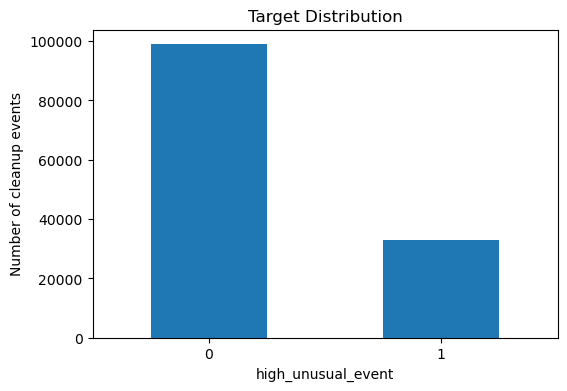

In [16]:
#this cell is to show the distribution of normal event and high unsual event in the data

target_counts = eda_data[target].value_counts().sort_index()
target_proportions = eda_data[target].value_counts(normalize=True).sort_index()
print("Target counts:")
print(target_counts)
print("\nTarget proportions:")
print(target_proportions)

#here we use matplot to draw the bar chart of target distribution
plt.figure(figsize=(6, 4))
target_counts.plot(kind="bar")
plt.title("Target Distribution")
plt.xlabel("high_unusual_event")
plt.ylabel("Number of cleanup events")
plt.xticks(rotation=0)
plt.show()

### High unusual debris event rate by year

This cell examines whether high-unusual-debris events vary over time. The yearly summary shows a clear upward trend, especially after 2021. The high-unusual-event rate increases from relatively low levels in 2016–2019 to much higher levels after 2022.

This pattern suggests that year may be an important predictor. However, this result should be interpreted carefully because the dataset changed its item category structure around 2023. Therefore, part of the year trend may reflect changes in reporting, data collection, or category definitions rather than a purely environmental change.

,year,number_of_events,high_unusual_rate
0,2015,878,0.191344
1,2016,5647,0.059324
2,2017,8032,0.061628
3,2018,9952,0.057677
4,2019,13781,0.040708
5,2020,14808,0.121151
6,2021,20384,0.162578
7,2022,14350,0.357700
8,2023,14415,0.445994
9,2024,14803,0.444302


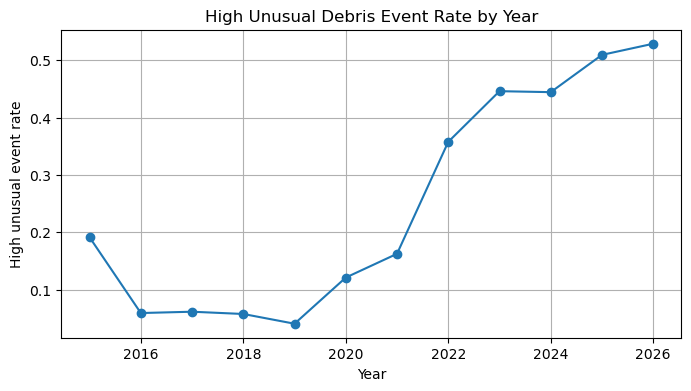

In [17]:
#show distribution across years
year_summary = eda_data.groupby("year")[target].agg(["count", "mean"]).reset_index()
year_summary = year_summary.rename(columns={"count": "number_of_events","mean": "high_unusual_rate"})
display(year_summary)

plt.figure(figsize=(8, 4))
plt.plot(year_summary["year"], year_summary["high_unusual_rate"], marker="o")
plt.title("High Unusual Debris Event Rate by Year")
plt.xlabel("Year")
plt.ylabel("High unusual event rate")
plt.grid(True)
plt.show()

### High unusual debris event rate by month

This cell examines seasonal variation in high-unusual-debris events. The event rate is highest around May and June and lowest in September.

This suggests that month may contain useful predictive information. However, the pattern does not simply match hurricane season. In particular, September has many cleanup events but a relatively low high-unusual rate, which may reflect large organized cleanup campaigns or different cleanup composition during that month.

,month,number_of_events,high_unusual_rate
0,1,5133,0.253653
1,2,4760,0.233824
2,3,6796,0.262802
3,4,11436,0.271424
4,5,9219,0.319774
5,6,9138,0.315167
6,7,8362,0.278881
7,8,7769,0.271850
8,9,43503,0.207043
9,10,13653,0.225518


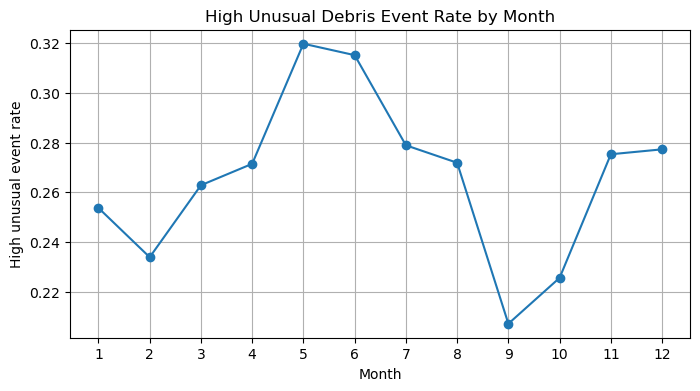

In [18]:
#showing the distribution of month
month_summary = eda_data.groupby("month")[target].agg(["count", "mean"]).reset_index()
month_summary = month_summary.rename(columns={"count": "number_of_events","mean": "high_unusual_rate"})
display(month_summary)

plt.figure(figsize=(8, 4))
plt.plot(month_summary["month"], month_summary["high_unusual_rate"], marker="o")
plt.title("High Unusual Debris Event Rate by Month")
plt.xlabel("Month")
plt.ylabel("High unusual event rate")
plt.xticks(range(1, 13))
plt.grid(True)
plt.show()

### Hurricane season comparison

This cell compares high-unusual-debris rates between hurricane season and non-hurricane season. Surprisingly, the high-unusual rate is slightly lower during hurricane season.

This does not mean hurricanes reduce unusual debris. The variable `hurricane_season` is only a broad seasonal indicator and does not identify whether a cleanup occurred after an actual storm. The lower hurricane-season rate may also be influenced by September, which has many cleanup events but a low high-unusual rate.

A more accurate storm-related analysis would require adding actual storm event data, such as whether a cleanup occurred within 7, 14, or 30 days after a hurricane or tropical storm.

,hurricane_season,number_of_events,high_unusual_rate
0,0,41986,0.274854
1,1,89923,0.238804


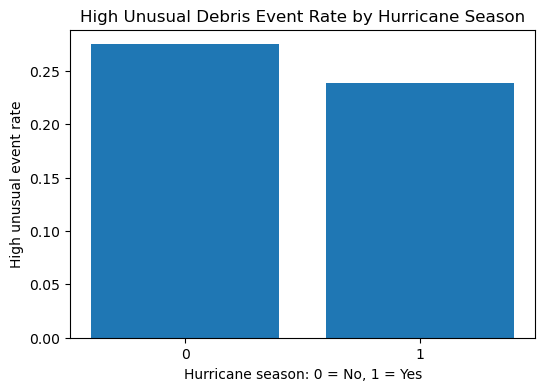

In [19]:
#this is to check whether hurricane season has any relationship with the high unusual event
hurricane_summary = eda_data.groupby("hurricane_season")[target].agg(["count", "mean"]).reset_index()
hurricane_summary = hurricane_summary.rename(columns={"count": "number_of_events","mean": "high_unusual_rate"})
display(hurricane_summary)

plt.figure(figsize=(6, 4))
plt.bar(hurricane_summary["hurricane_season"],hurricane_summary["high_unusual_rate"])
plt.title("High Unusual Debris Event Rate by Hurricane Season")
plt.xlabel("Hurricane season: 0 = No, 1 = Yes")
plt.ylabel("High unusual event rate")
plt.xticks([0, 1])
plt.show()

### High unusual debris event rate by state

This cell compares high-unusual-debris event rates across states. To avoid unstable rates from states with very few observations, the analysis only includes states with at least 200 cleanup events.

The result shows that some states, such as Alaska, Connecticut, Maine, South Carolina, and Hawaii, have relatively high high-unusual-event rates. This suggests that location may be an important predictor.

However, state-level differences should be interpreted carefully. They may reflect real coastal differences, different cleanup environments, different volunteer reporting practices, or differences in the types of cleanup events conducted in each state.

,state_name,number_of_events,high_unusual_rate
1,Alaska,463,0.548596
6,Connecticut,3883,0.417461
19,Maine,1075,0.398140
41,South Carolina,3083,0.394745
11,Hawaii,1831,0.379574
29,New Hampshire,567,0.361552
48,Virginia,4361,0.336620
40,Rhode Island,3828,0.327325
0,Alabama,1033,0.316554
2,Arizona,230,0.300000


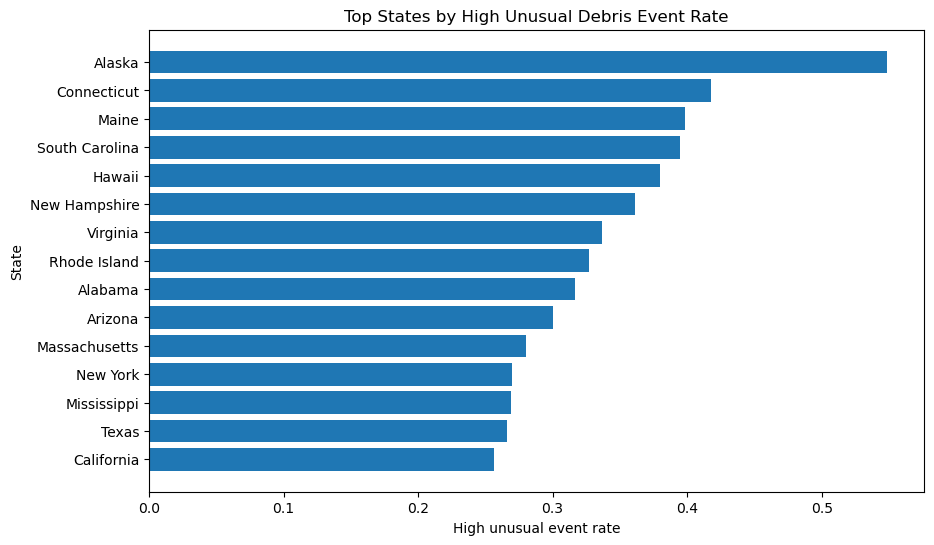

In [20]:
#this cell is to check the relationship of high unusual event by state
state_summary = eda_data.groupby("state_name")[target].agg(["count", "mean"]).reset_index()
state_summary = state_summary.rename(columns={"count": "number_of_events","mean": "high_unusual_rate"})
# Keep only states with enough events, so the rate is more reliable
min_events = 200
state_summary_filtered = state_summary[state_summary["number_of_events"] >= min_events].copy()
state_summary_filtered = state_summary_filtered.sort_values("high_unusual_rate",ascending=False)
display(state_summary_filtered.head(20))

plt.figure(figsize=(10, 6))
top_states = state_summary_filtered.head(15)
plt.barh(top_states["state_name"], top_states["high_unusual_rate"])
plt.title("Top States by High Unusual Debris Event Rate")
plt.xlabel("High unusual event rate")
plt.ylabel("State")
plt.gca().invert_yaxis()
plt.show()

### High unusual debris event rate by cleanup type

This cell examines whether cleanup type is related to high-unusual-debris events. Watercraft cleanups have the highest high-unusual rate, followed by land cleanups and underwater cleanups.

The differences are not extremely large, but they suggest that cleanup type may still provide useful information for prediction. This feature should be included in the first machine learning model.

,Cleanup Type,number_of_events,high_unusual_rate
2,watercraft,1895,0.284433
0,land,129517,0.249867
1,underwater,497,0.227364


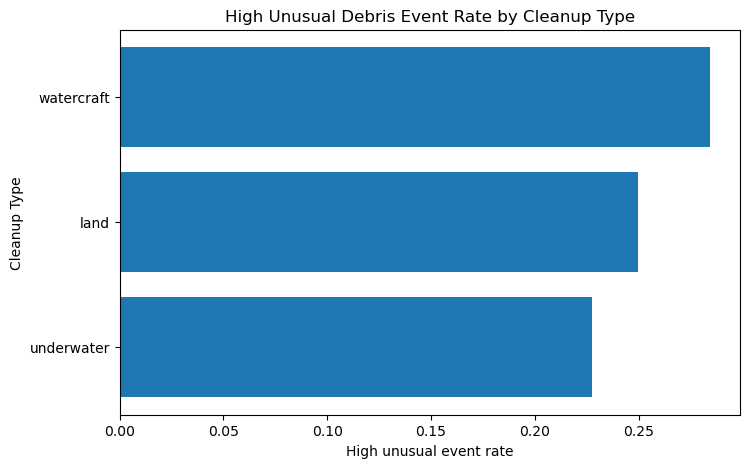

In [21]:
#this cell is to check the relationship of high unusual event rate by cleanup type
cleanup_type_summary = eda_data.groupby("Cleanup Type")[target].agg(["count", "mean"]).reset_index()
cleanup_type_summary = cleanup_type_summary.rename(columns={"count": "number_of_events","mean": "high_unusual_rate"})
cleanup_type_summary = cleanup_type_summary.sort_values("high_unusual_rate",ascending=False)
display(cleanup_type_summary)

plt.figure(figsize=(8, 5))
plt.barh(cleanup_type_summary["Cleanup Type"],cleanup_type_summary["high_unusual_rate"])
plt.title("High Unusual Debris Event Rate by Cleanup Type")
plt.xlabel("High unusual event rate")
plt.ylabel("Cleanup Type")
plt.gca().invert_yaxis()
plt.show()

### EDA summary

The exploratory analysis shows several useful patterns:

1. The target variable is correctly constructed, with approximately 75% normal events and 25% high-unusual-debris events.
2. High-unusual-debris rates vary strongly by year, especially after 2021. This suggests that year is predictive, but the pattern may partly reflect changes in reporting or category structure.
3. Month shows seasonal variation. May and June have relatively high high-unusual rates, while September has a low rate despite a large number of cleanup events.
4. The broad hurricane-season indicator does not show a higher high-unusual rate. More precise storm data would be needed to test post-storm effects.
5. State-level differences are substantial, suggesting that location is likely important.
6. Cleanup type shows moderate differences, with watercraft cleanups having the highest high-unusual rate.